## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
MONTH = 8

In [3]:
years = range(2024, 2026)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2024 | (52992, 102)
Year: 2025 | (35328, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2024-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2024,1,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,0.938387,3.685806,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.8524,3.685806,6.480000,8.280968,16.144800,1.467828,7.611751,16.225668,45.498087,45.502681,45.502681,-6.610,12.870,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN
1,0,2024-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2024,2,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,2.737586,6.480000,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.8524,3.685806,6.480000,8.280968,16.144800,1.294299,18.881823,18.951474,37.534668,83.037349,37.534668,-5.290,14.110,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN
2,0,2024-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2024,3,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,2.594516,8.280968,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.8524,3.685806,6.480000,8.280968,16.144800,1.551360,11.947780,14.171614,29.937022,129.578139,46.540790,-4.570,24.350,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN
3,0,2024-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2024,4,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,8.852400,16.144800,6.433226,10.222414,13.967419,23.437200,0.938387,2.737586,2.594516,8.8524,3.685806,6.480000,8.280968,16.144800,2.423561,0.703507,60.256993,70.283258,199.861397,70.283258,-1.550,29.210,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,8195.0,38069.0,13922.0,60186.

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

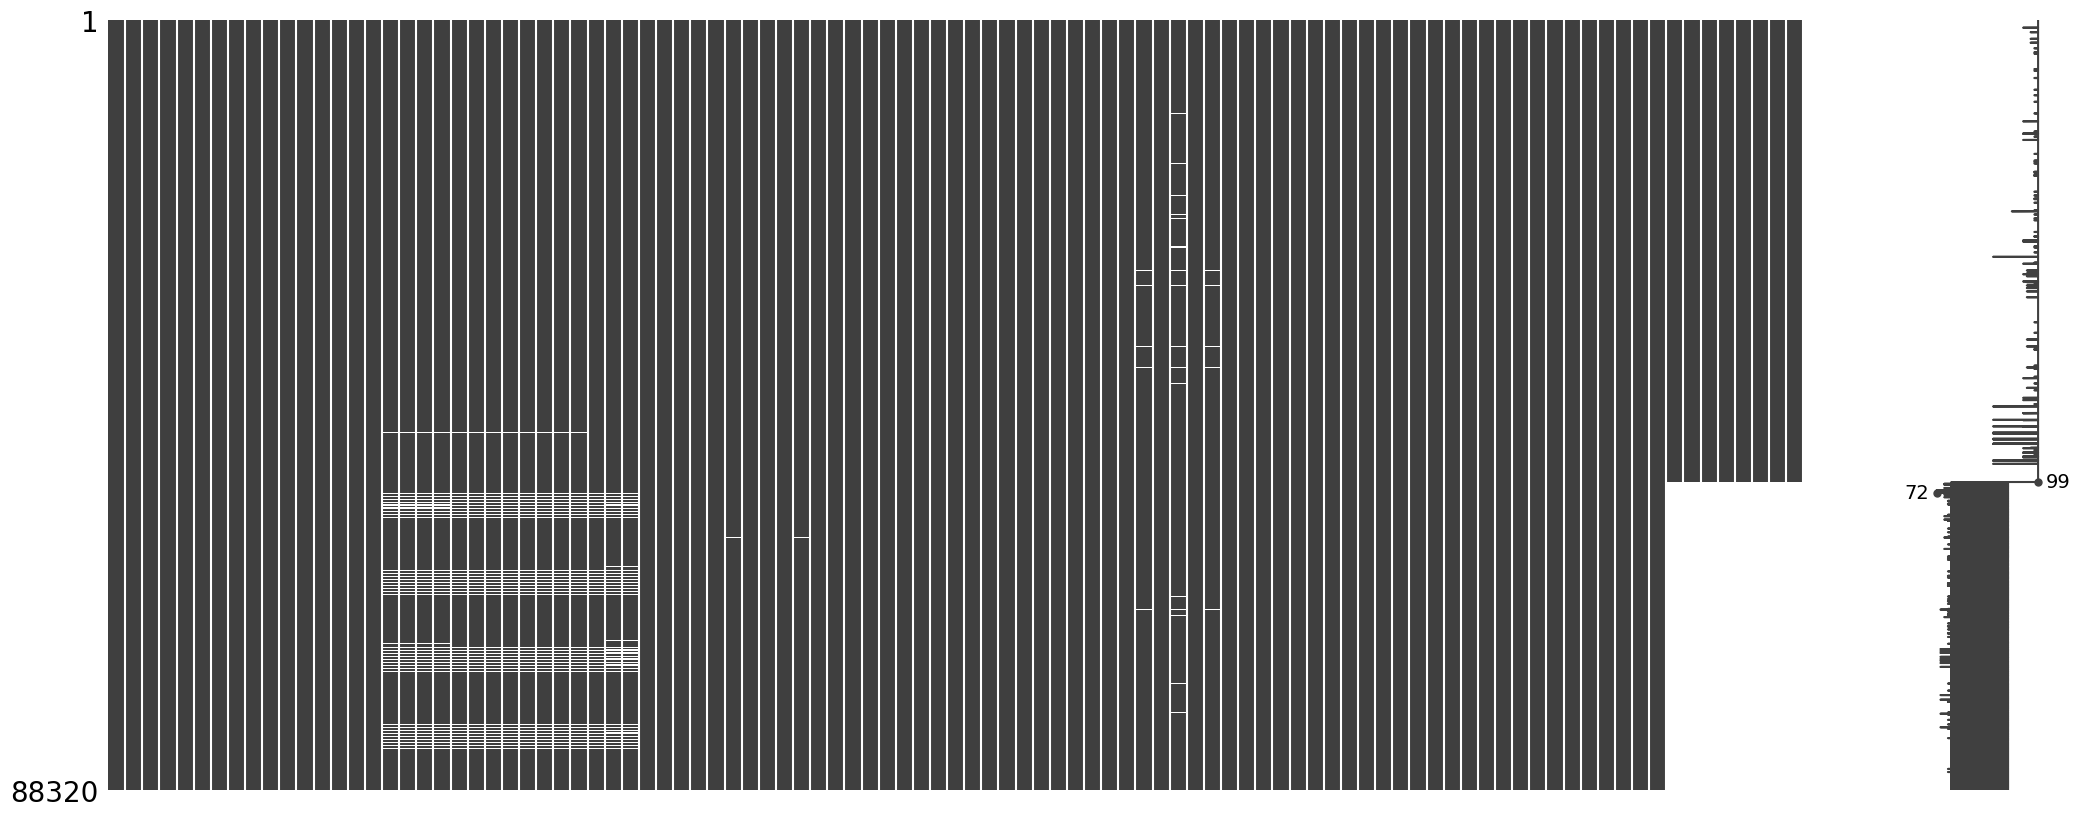

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,5.2163
17,ndmi,5.2163
18,ndwi,5.2163
19,ndbi,5.2163
20,ndvi_mean,5.0804
...,...,...
97,F_Y_GE65,40.0000
98,F_TOTAL,40.0000
99,MIO_EUR,100.0000
100,L_TOTAL,100.0000


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_NAME', 'NUTS1_ID', 'rainfall_acc']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2024-01,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,1,2024,0.267415,0.083574,-0.257810,-0.083574,0.241783,0.021266,-0.224117,-0.021266,0.021016,0.055956,0.024599,0.055956,6.433226,6.433226,10.222414,13.967419,23.437200,0.938387,0.938387,2.737586,2.594516,8.8524,3.685806,3.685806,6.480000,8.280968,16.144800,-6.610,12.870,1.467828,7.611751,16.225668,45.498087,45.502681,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
1,2024-02,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,2,2024,0.244531,0.146571,-0.258886,-0.146571,0.290309,-0.085296,-0.307094,0.085296,0.023339,0.022974,0.011478,0.022974,10.222414,6.433226,10.222414,13.967419,23.437200,2.737586,0.938387,2.737586,2.594516,8.8524,6.480000,3.685806,6.480000,8.280968,16.144800,-5.290,14.110,1.294299,18.881823,18.951474,37.534668,83.037349,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
2,2024-03,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,3,2024,0.324030,-0.109920,-0.337069,0.109920,0.306936,-0.100461,-0.321696,0.100461,0.025461,0.024213,0.015288,0.024213,13.967419,6.433226,10.222414,13.967419,23.437200,2.594516,0.938387,2.737586,2.594516,8.8524,8.280968,3.685806,6.480000,8.280968,16.144800,-4.570,24.350,1.551360,11.947780,14.171614,29.937022,129.578139,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
3,2024-04,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,4,2024,0.498411,0.043862,-0.419718,-0.043862,0.471756,0.023727,-0.406067,-0.023727,0.044087,0.046540,0.023812,0.046540,23.437200,6.433226,10.222414,13.967419,23.437200,8.852400,0.938387,2.737586,2.594516,8.8524,16.144800,3.685806,6.480000,8.280968,16.144800,-1.550,29.210,2.423561,0.703507,60.256993,70.283258,199.861397,14.0,20.00,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,31,80.0,30,80.0,30,80.0,10,10,1,6,6,2,0,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
4,2024-05,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,5,2024,0.666505,0.221835,-

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
months = range(1,MONTH+1)

In [19]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2025 | Month: 1
Year: 2025 | Month: 2
Year: 2025 | Month: 3
Year: 2025 | Month: 4
Year: 2025 | Month: 5
Year: 2025 | Month: 6
Year: 2025 | Month: 7
Year: 2025 | Month: 8


In [20]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE


In [21]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2024)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type


<Axes: >

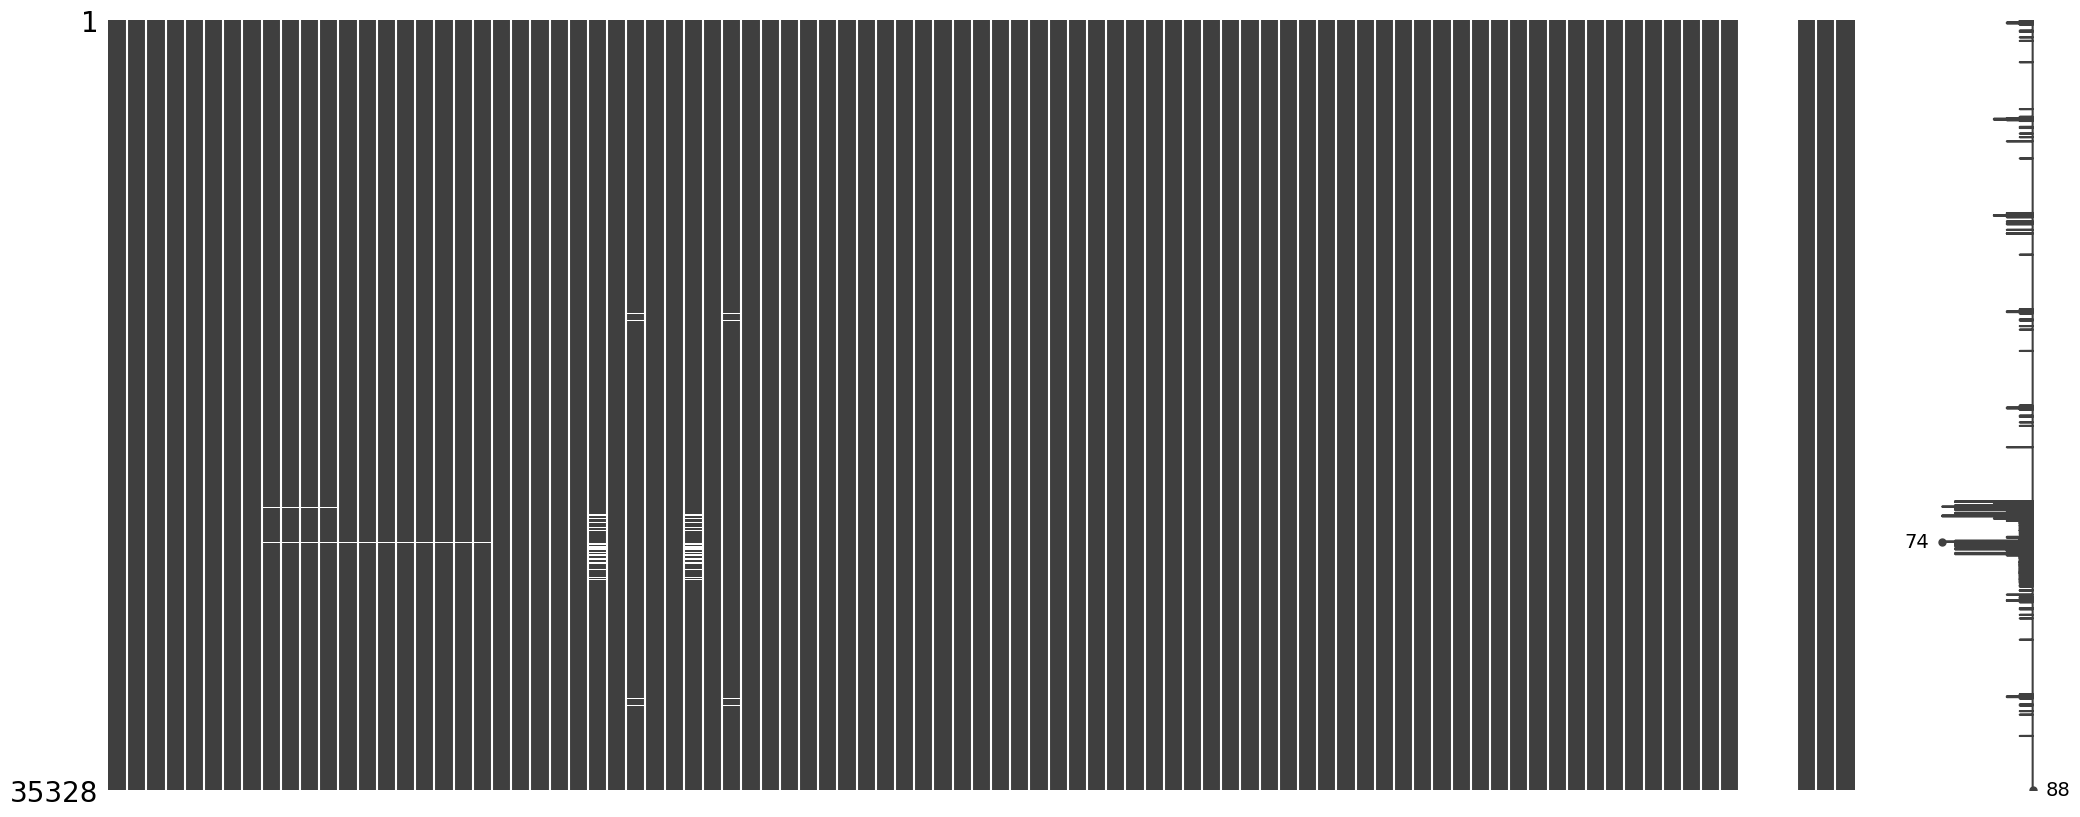

In [22]:
missingno.matrix(dataset_operational)

In [23]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,0.3651
9,ndmi,0.3651
10,ndwi,0.3651
11,ndbi,0.3651
12,ndvi_mean,0.1330
...,...,...
32,lst_feb_mean,0.3170
34,lst_apr_mean,0.0226
85,mio_eur,100.0000
86,l_total,100.0000


In [24]:
# dataset_monthly.cases.sum()

In [25]:
# dataset_operational.cases.sum()

In [26]:
years = dataset_operational.year.unique().tolist()

In [27]:
years

[2025]

In [28]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)